#  Lung Cancer Detection using CNN + Transfer Learning
### Dataset: LC25000 — Lung and Colon Cancer Histopathological Images

**Classes Detected:**
-  `lung_n` → Normal / Benign Lung Tissue
-  `lung_aca` → Lung Adenocarcinoma
-  `lung_scc` → Lung Squamous Cell Carcinoma

**Models Used:** Custom CNN | VGG16 | ResNet50 | EfficientNetB0

---
> **Instructions:** Run each cell from top to bottom. GPU runtime recommended (Runtime → Change runtime type → T4 GPU)

##  Cell 1 — Install & Import Libraries

In [1]:
# Install required packages
!pip install kaggle tensorflow keras matplotlib seaborn scikit-learn Pillow ipywidgets -q

import os, shutil, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io, base64

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f' TensorFlow version: {tf.__version__}')
print(f' GPU Available: {"YES — " + gpus[0].name if gpus else "No GPU (using CPU)"}')
print(' All libraries loaded successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.5 MB/s eta 0:00:00
 TensorFlow version: 2.19.0
 GPU Available: YES — /physical_device:GPU:0
 All libraries loaded successfully!


##  Cell 2 — Download Dataset from Kaggle
>


In [3]:
# Download and unzip the dataset
print(' Downloading LC25000 dataset... (this may take a few minutes)')
!kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images

print(' Extracting dataset...')
with zipfile.ZipFile('lung-and-colon-cancer-histopathological-images.zip', 'r') as z:
    z.extractall('dataset')

print(' Dataset extracted!')

# Find the lung image folder
for root, dirs, files_list in os.walk('dataset'):
    for d in dirs:
        print(f'   {os.path.join(root, d)}')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
100% 1.76G/1.76G [02:00<00:00, 15.6MB/s]

 Extracting dataset...
 Dataset extracted!
   dataset/lung_colon_image_set
   dataset/lung_colon_image_set/colon_image_sets
   dataset/lung_colon_image_set/lung_image_sets
   dataset/lung_colon_image_set/colon_image_sets/colon_aca
   dataset/lung_colon_image_set/colon_image_sets/colon_n
   dataset/lung_colon_image_set/lung_image_sets/lung_scc
   dataset/lung_colon_image_set/lung_image_sets/lung_aca
   dataset/lung_colon_image_set/lung_image_sets/lung_n


##  Cell 3 — Configuration & Dataset Setup

In [ ]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
IMG_SIZE     = 224          # Image size for all models
BATCH_SIZE   = 32
EPOCHS       = 20           # Increase for better accuracy
LEARNING_RATE = 1e-4
SEED         = 42

CLASS_NAMES = ['lung_aca', 'lung_n', 'lung_scc']
CLASS_LABELS = {
    'lung_aca': ' Lung Adenocarcinoma',
    'lung_n':   ' Normal Lung Tissue',
    'lung_scc': ' Lung Squamous Cell Carcinoma'
}
CLASS_COLORS = ['#e74c3c', '#2ecc71', '#f39c12']

# ─── FIND DATASET PATH ───────────────────────────────────────────────────────
BASE_DATA_PATH = None
for root, dirs, _ in os.walk('dataset'):
    if 'lung_image_sets' in dirs:
        BASE_DATA_PATH = os.path.join(root, 'lung_image_sets')
        break

if BASE_DATA_PATH is None:
    # Fallback: search directly
    for root, dirs, _ in os.walk('dataset'):
        if any(c in dirs for c in CLASS_NAMES):
            BASE_DATA_PATH = root
            break

print(f' Dataset path: {BASE_DATA_PATH}')
for cls in CLASS_NAMES:
    p = os.path.join(BASE_DATA_PATH, cls)
    if os.path.exists(p):
        count = len(os.listdir(p))
        print(f'   {CLASS_LABELS[cls]}: {count} images')

 Dataset path: dataset/lung_colon_image_set/lung_image_sets
    Lung Adenocarcinoma: 5000 images
    Normal Lung Tissue: 5000 images
    Lung Squamous Cell Carcinoma: 5000 images


##  Cell 4 — Explore & Visualize Dataset

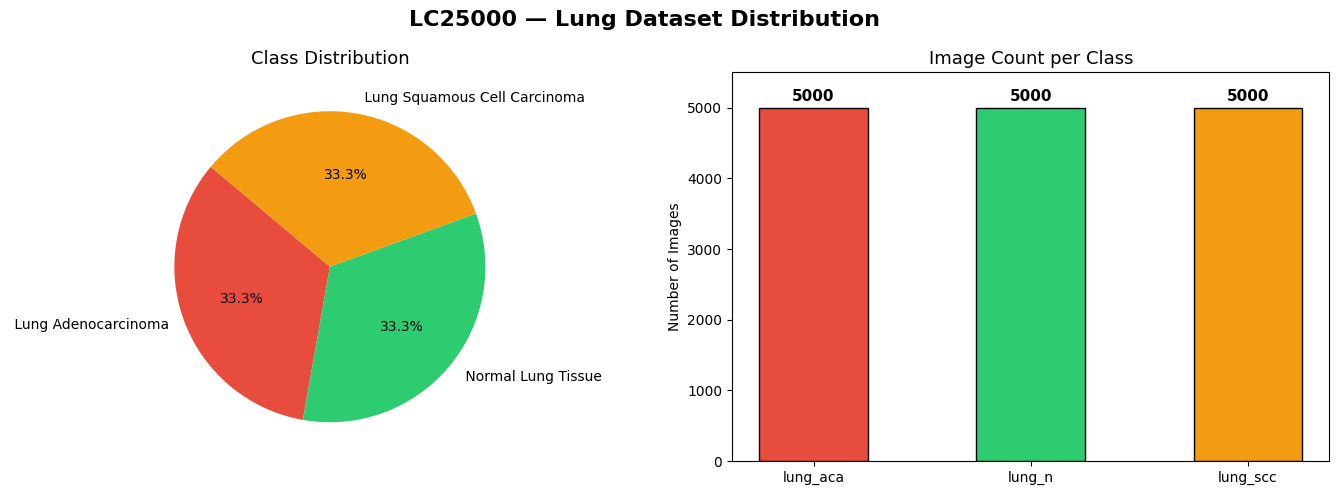

 Dataset distribution plotted!


In [ ]:
# ─── DATASET DISTRIBUTION PIE + BAR ──────────────────────────────────────────
counts = []
for cls in CLASS_NAMES:
    p = os.path.join(BASE_DATA_PATH, cls)
    counts.append(len(os.listdir(p)) if os.path.exists(p) else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LC25000 — Lung Dataset Distribution', fontsize=16, fontweight='bold')

# Pie chart
labels = [CLASS_LABELS[c] for c in CLASS_NAMES]
axes[0].pie(counts, labels=labels, colors=CLASS_COLORS, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Class Distribution', fontsize=13)

# Bar chart
bars = axes[1].bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='black', width=0.5)
axes[1].set_title('Image Count per Class', fontsize=13)
axes[1].set_ylabel('Number of Images')
axes[1].set_ylim(0, max(counts) + 500)
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(cnt), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dataset distribution plotted!')

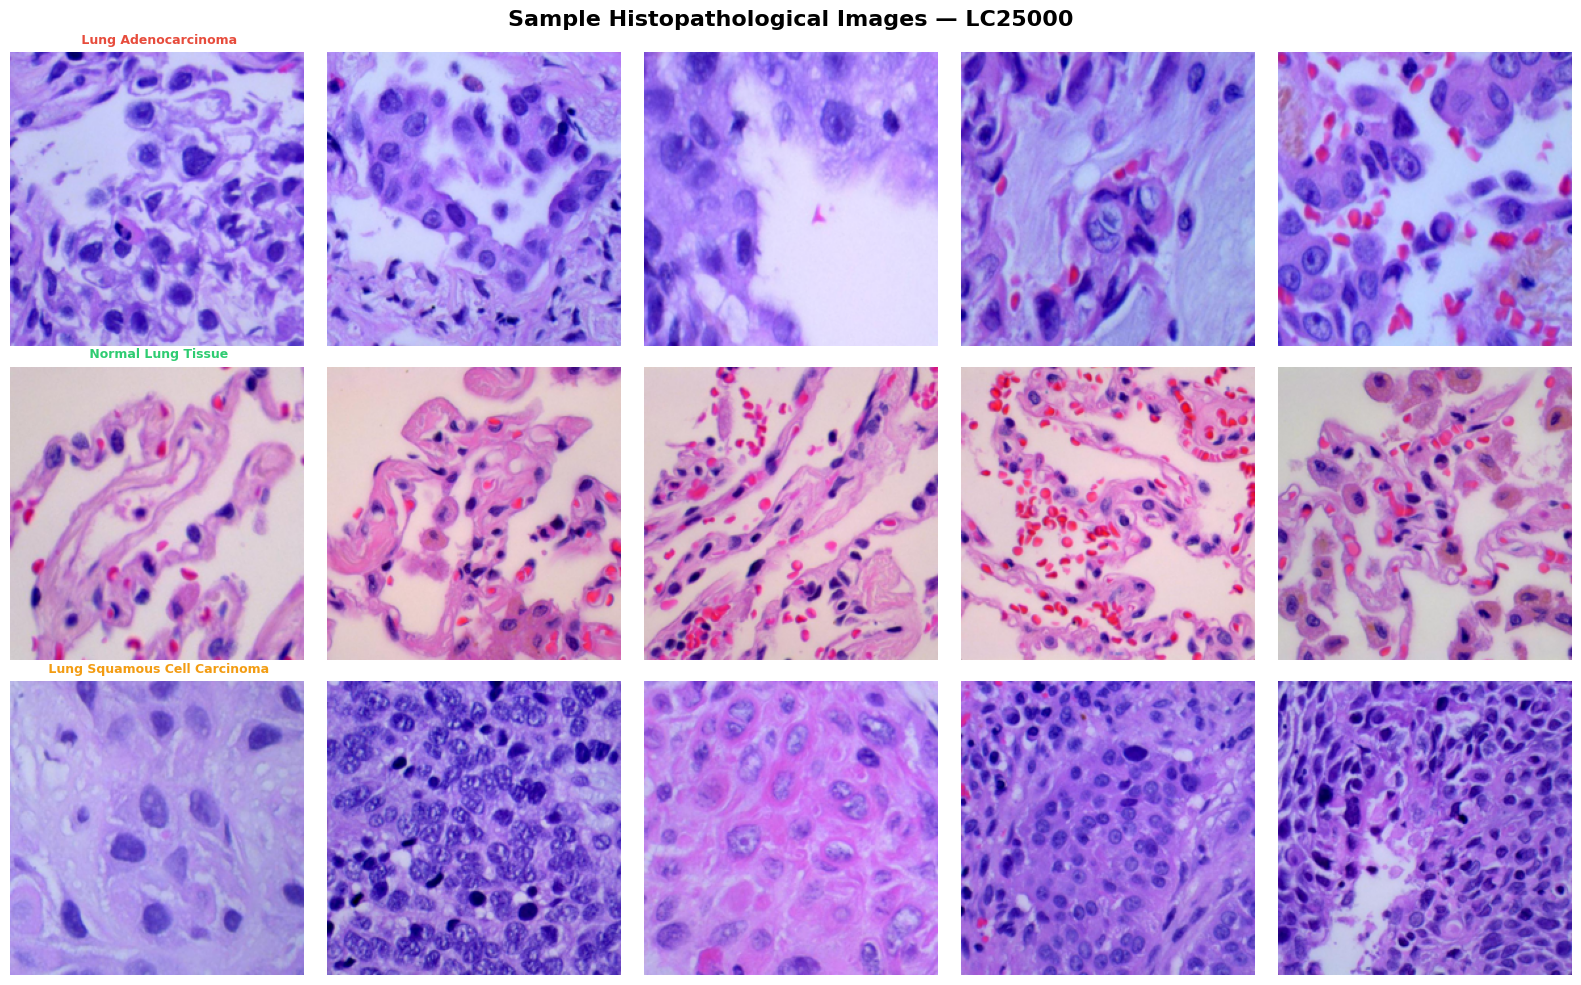

 Sample images displayed!


In [ ]:
# ─── SAMPLE IMAGE GRID ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Sample Histopathological Images — LC25000', fontsize=16, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(BASE_DATA_PATH, cls)
    imgs = random.sample(os.listdir(cls_path), 5)
    for col_idx, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name)).resize((224, 224))
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_title(CLASS_LABELS[cls], fontsize=9,
                                              color=CLASS_COLORS[row_idx], fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sample images displayed!')

##  Cell 5 — Data Preprocessing & Augmentation

In [ ]:
# ─── SPLIT INTO TRAIN / VAL / TEST ───────────────────────────────────────────
SPLIT_DIR = 'split_data'
SPLITS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

def split_dataset(src, dst, splits, seed=42):
    random.seed(seed)
    if os.path.exists(dst):
        shutil.rmtree(dst)
    for split in splits:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(dst, split, cls), exist_ok=True)

    for cls in CLASS_NAMES:
        imgs = os.listdir(os.path.join(src, cls))
        random.shuffle(imgs)
        n = len(imgs)
        t = int(n * splits['train'])
        v = int(n * splits['val'])
        split_map = {'train': imgs[:t], 'val': imgs[t:t+v], 'test': imgs[t+v:]}
        for split, files_list in split_map.items():
            for f in files_list:
                shutil.copy(os.path.join(src, cls, f), os.path.join(dst, split, cls, f))
    return dst

split_dataset(BASE_DATA_PATH, SPLIT_DIR, SPLITS)

for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(os.path.join(SPLIT_DIR, split, c))) for c in CLASS_NAMES)
    print(f'  {split.upper():5s}: {total} images')
print(' Dataset split complete!')

  TRAIN: 10500 images
  VAL  : 2250 images
  TEST : 2250 images
 Dataset split complete!


In [ ]:
# ─── DATA GENERATORS ─────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, split, shuffle=True):
    return datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, split),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, 'train', shuffle=True)
val_gen   = make_generator(val_test_datagen, 'val', shuffle=False)
test_gen  = make_generator(val_test_datagen, 'test', shuffle=False)

print(f' Train batches: {len(train_gen)}')
print(f' Val   batches: {len(val_gen)}')
print(f' Test  batches: {len(test_gen)}')
print(f' Class indices: {train_gen.class_indices}')

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
 Train batches: 329
 Val   batches: 71
 Test  batches: 71
 Class indices: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


##  Cell 6 — Build Models

In [ ]:
# ─── MODEL BUILDER FUNCTIONS ──────────────────────────────────────────────────
NUM_CLASSES = len(CLASS_NAMES)

def build_custom_cnn():
    """Custom CNN built from scratch"""
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Custom_CNN')
    return model


def build_transfer_model(base_name='EfficientNetB0'):
    """Transfer learning model: VGG16 / ResNet50 / EfficientNetB0"""
    bases = {
        'VGG16':          VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)),
        'ResNet50':       ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)),
        'EfficientNetB0': EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3)),
    }
    base = bases[base_name]
    # Freeze base layers initially
    base.trainable = False

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inp, out, name=base_name)
    return model


# Instantiate all models
model_dict = {
    'Custom_CNN':     build_custom_cnn(),
    'VGG16':          build_transfer_model('VGG16'),
    'ResNet50':        build_transfer_model('ResNet50'),
    'EfficientNetB0': build_transfer_model('EfficientNetB0'),
}

for name, m in model_dict.items():
    m.compile(optimizer=Adam(LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    print(f' {name:20s} — Parameters: {m.count_params():,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Custom_CNN           — Parameters: 849,827
 VGG16                — Parameters: 15,111,491
 ResNet50             — Parameters: 24,770,947
 EfficientNetB0       — Parameters: 4,839,590


##  Cell 7 — Train All Models

In [ ]:
# ─── CALLBACKS ───────────────────────────────────────────────────────────────
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

# ─── TRAIN ALL MODELS ────────────────────────────────────────────────────────
histories = {}
results   = {}

for model_name, model in model_dict.items():
    print(f'\n{"="*60}')
    print(f' Training: {model_name}')
    print(f'{"="*60}')

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    histories[model_name] = history

    # Evaluate on test set
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    results[model_name] = {'test_accuracy': acc, 'test_loss': loss}
    print(f' {model_name} — Test Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}')

print('\n All models trained!')


🚀 Training: Custom_CNN
Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8672 - loss: 0.3448

329/329 ━━━━━━━━━━━━━━━━━━━━ 186s 566ms/step - accuracy: 0.8748 - loss: 0.3188 - val_accuracy: 0.3431 - val_loss: 5.0050 - learning_rate: 1.0000e-04
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.8827 - loss: 0.2881

329/329 ━━━━━━━━━━━━━━━━━━━━ 185s 561ms/step - accuracy: 0.8854 - loss: 0.2773 - val_accuracy: 0.4542 - val_loss: 5.1037 - learning_rate: 1.0000e-04
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 183s 555ms/step - accuracy: 0.9069 - loss: 0.2362 - val_accuracy: 0.3431 - val_loss: 8.9761 - learning_rate: 1.0000e-04
Epoch 4/20
 64/329 ━━━━━━━━━━━━━━━━━━━━ 2:21 534ms/step - accuracy: 0.9199 - loss: 0.2145

##  Cell 8 — Training History Graphs

In [ ]:
# ─── PLOT TRAINING CURVES FOR ALL MODELS ─────────────────────────────────────
fig, axes = plt.subplots(len(model_dict), 2, figsize=(16, 5 * len(model_dict)))
fig.suptitle('Training History — All Models', fontsize=18, fontweight='bold', y=1.01)

colors = ['#3498db', '#e74c3c']

for idx, (model_name, history) in enumerate(histories.items()):
    h = history.history
    epochs_ran = range(1, len(h['accuracy']) + 1)

    # Accuracy
    ax1 = axes[idx][0]
    ax1.plot(epochs_ran, h['accuracy'],     color=colors[0], linewidth=2, label='Train Acc')
    ax1.plot(epochs_ran, h['val_accuracy'], color=colors[1], linewidth=2, linestyle='--', label='Val Acc')
    ax1.set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # Loss
    ax2 = axes[idx][1]
    ax2.plot(epochs_ran, h['loss'],     color=colors[0], linewidth=2, label='Train Loss')
    ax2.plot(epochs_ran, h['val_loss'], color=colors[1], linewidth=2, linestyle='--', label='Val Loss')
    ax2.set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Training curves plotted!')

##  Cell 9 — Model Comparison Graph

In [ ]:
# ─── COMPARISON BAR CHART ────────────────────────────────────────────────────
model_names = list(results.keys())
test_accs   = [results[m]['test_accuracy'] * 100 for m in model_names]
test_losses = [results[m]['test_loss'] for m in model_names]

x = np.arange(len(model_names))
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Model Comparison — Test Set Performance', fontsize=16, fontweight='bold')

# Accuracy bar
bars1 = axes[0].bar(x, test_accs, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].set_ylim(0, 115); axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Loss bar
bars2 = axes[1].bar(x, test_losses, color=bar_colors, edgecolor='black', width=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=11)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Test Loss Comparison', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, test_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Best model summary
best_model_name = max(results, key=lambda m: results[m]['test_accuracy'])
print(f'\n BEST MODEL: {best_model_name}')
print(f'   Test Accuracy: {results[best_model_name]["test_accuracy"]*100:.2f}%')
print(f'   Test Loss:     {results[best_model_name]["test_loss"]:.4f}')

##  Cell 10 — Confusion Matrix & Classification Report

In [ ]:
# ─── CONFUSION MATRICES FOR ALL MODELS ───────────────────────────────────────
fig, axes = plt.subplots(1, len(model_dict), figsize=(6 * len(model_dict), 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=16, fontweight='bold')

display_names = ['lung_aca', 'lung_n', 'lung_scc']

for idx, (model_name, model) in enumerate(model_dict.items()):
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    ax = axes[idx] if len(model_dict) > 1 else axes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=display_names, yticklabels=display_names,
                linewidths=0.5)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Best model classification report
print(f'\n📋 Classification Report — Best Model ({best_model_name}):')
best_model = model_dict[best_model_name]
test_gen.reset()
preds = best_model.predict(test_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
print(classification_report(y_true, y_pred, target_names=display_names))

##  Cell 11 — Per-Class Accuracy Radar / Bar Chart

In [ ]:
# ─── PER-CLASS ACCURACY GROUPED BAR ──────────────────────────────────────────
from sklearn.metrics import classification_report as cr
import json

per_class_acc = {}
for model_name, model in model_dict.items():
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes
    report = cr(y_true, y_pred, target_names=display_names, output_dict=True)
    per_class_acc[model_name] = {c: report[c]['f1-score'] for c in display_names}

x = np.arange(len(display_names))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Per-Class F1-Score Comparison — All Models', fontsize=15, fontweight='bold')

for i, (mname, scores) in enumerate(per_class_acc.items()):
    vals = [scores[c] for c in display_names]
    bars = ax.bar(x + i * width, vals, width, label=mname,
                  color=bar_colors[i], edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(display_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Per-class F1 chart plotted!')

##  Cell 12 — Grad-CAM Heatmap (Explainability)

In [ ]:
# ─── GRAD-CAM IMPLEMENTATION ──────────────────────────────────────────────────
import tensorflow as tf
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    try:
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
        return heatmap.numpy()
    except:
        return None


def get_last_conv_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    return None


# Show Grad-CAM for 3 test samples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle(f'Grad-CAM Heatmaps — {best_model_name}', fontsize=15, fontweight='bold')

best_model = model_dict[best_model_name]
last_conv  = get_last_conv_name(best_model)

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(SPLIT_DIR, 'test', cls)
    sample   = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, sample)
    img_orig = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_arr  = np.array(img_orig) / 255.0
    img_input = np.expand_dims(img_arr, 0)

    preds     = best_model.predict(img_input, verbose=0)
    pred_cls  = CLASS_NAMES[np.argmax(preds)]
    confidence = np.max(preds) * 100

    heatmap = get_gradcam_heatmap(best_model, img_input, last_conv) if last_conv else None

    # Original
    axes[row_idx][0].imshow(img_orig); axes[row_idx][0].axis('off')
    axes[row_idx][0].set_title(f'Original\nActual: {cls}', fontsize=9)

    # Heatmap
    if heatmap is not None:
        hm_resized = np.uint8(255 * heatmap)
        hm_color   = cv2.applyColorMap(cv2.resize(hm_resized, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)
        hm_rgb     = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
        axes[row_idx][1].imshow(hm_rgb); axes[row_idx][1].axis('off')
        axes[row_idx][1].set_title('Grad-CAM Heatmap', fontsize=9)

        # Overlay
        overlay = np.uint8(0.6 * np.array(img_orig) + 0.4 * hm_rgb)
        axes[row_idx][2].imshow(overlay); axes[row_idx][2].axis('off')
    else:
        axes[row_idx][1].imshow(img_orig); axes[row_idx][1].axis('off')
        axes[row_idx][2].imshow(img_orig); axes[row_idx][2].axis('off')

    status = '' if pred_cls == cls else '❌'
    axes[row_idx][2].set_title(f'{status} Pred: {pred_cls}\nConf: {confidence:.1f}%', fontsize=9)

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Grad-CAM visualization complete!')

## 🎯 Cell 13 — Final Results Summary Table

In [ ]:
# ─── SUMMARY TABLE ───────────────────────────────────────────────────────────
summary_data = []
for model_name in model_dict:
    r = results[model_name]
    best_val_acc = max(histories[model_name].history['val_accuracy']) * 100
    best_train_acc = max(histories[model_name].history['accuracy']) * 100
    summary_data.append({
        'Model': model_name,
        'Train Acc (%)': f'{best_train_acc:.2f}',
        'Val Acc (%)':   f'{best_val_acc:.2f}',
        'Test Acc (%)':  f'{r["test_accuracy"]*100:.2f}',
        'Test Loss':     f'{r["test_loss"]:.4f}',
        'Rank': ''
    })

df = pd.DataFrame(summary_data)
df = df.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)
df['Rank'] = ['🥇', '🥈', '🥉', '4th'][:len(df)]

print('\n' + '='*65)
print('            FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(df.to_string(index=False))
print('='*65)
print(f'\n Best Model: {df.iloc[0]["Model"]} with {df.iloc[0]["Test Acc (%)"] }% Test Accuracy')

# Save results CSV
df.to_csv('model_results.csv', index=False)
print(' Results saved to model_results.csv')

##  Cell 14 — Upload Image & Predict (Interactive)

In [ ]:
# ─── INTERACTIVE PREDICTION UI ───────────────────────────────────────────────

CLASS_FULL_NAMES = {
    'lung_aca': ' Lung Adenocarcinoma (Cancerous)',
    'lung_n':   ' Normal Lung Tissue (Benign)',
    'lung_scc': ' Lung Squamous Cell Carcinoma (Cancerous)'
}

RISK_INFO = {
    'lung_aca': ('HIGH RISK', '#e74c3c', 'Malignant — Immediate medical consultation recommended.'),
    'lung_n':   ('NO RISK',   '#2ecc71', 'Benign tissue. No cancer detected. Regular checkups advised.'),
    'lung_scc': ('HIGH RISK', '#e67e22', 'Malignant — Immediate medical consultation recommended.')
}

# ── WIDGETS ──
upload_btn   = widgets.FileUpload(accept='image/*', multiple=False,
                                   description='Upload Image', button_style='info')
model_select = widgets.Dropdown(
    options=list(model_dict.keys()),
    value=best_model_name,
    description='Model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)
predict_btn  = widgets.Button(description=' Predict', button_style='success',
                               layout=widgets.Layout(width='150px', height='40px'))
clear_btn    = widgets.Button(description='🗑 Clear', button_style='warning',
                               layout=widgets.Layout(width='100px', height='40px'))
output_area  = widgets.Output()

title_html = widgets.HTML("""
<div style='background: linear-gradient(135deg,#1a1a2e,#16213e); padding:20px;
     border-radius:12px; text-align:center; margin-bottom:15px;'>
  <h2 style='color:#00d4ff; margin:0;'> Lung Cancer Detection System</h2>
  <p style='color:#aaa; margin:5px 0 0;'>Upload a histopathological image and select a model</p>
</div>
""")

def preprocess_image(img):
    img = img.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img) / 255.0
    return np.expand_dims(arr, axis=0), img

def on_predict(b):
    output_area.clear_output(wait=True)
    with output_area:
        if not upload_btn.value:
            print('  Please upload an image first!')
            return

        # Load image
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file['content']
        img = Image.open(io.BytesIO(img_bytes))
        img_input, img_disp = preprocess_image(img)

        # Predict with selected model
        selected_model = model_dict[model_select.value]
        preds = selected_model.predict(img_input, verbose=0)[0]
        pred_idx  = np.argmax(preds)
        pred_cls  = CLASS_NAMES[pred_idx]
        confidence = preds[pred_idx] * 100

        risk_label, risk_color, risk_msg = RISK_INFO[pred_cls]

        # ── RESULT DISPLAY ──
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.patch.set_facecolor('#0f0f1a')
        fig.suptitle(f'Prediction Result — Model: {model_select.value}',
                     fontsize=14, color='white', fontweight='bold')

        # Image
        axes[0].imshow(img_disp)
        axes[0].set_title('Input Image', color='white', fontsize=12)
        axes[0].axis('off')
        axes[0].set_facecolor('#1a1a2e')

        # Confidence bar
        bar_cols = [CLASS_COLORS[i] for i in range(len(CLASS_NAMES))]
        bars = axes[1].barh(CLASS_NAMES, preds * 100, color=bar_cols, edgecolor='white')
        axes[1].set_xlim(0, 115)
        axes[1].set_xlabel('Confidence (%)', color='white')
        axes[1].set_title('Class Probabilities', color='white', fontsize=12)
        axes[1].tick_params(colors='white')
        axes[1].set_facecolor('#1a1a2e')
        for spine in axes[1].spines.values(): spine.set_color('#444')
        for bar, p in zip(bars, preds * 100):
            axes[1].text(p + 1, bar.get_y() + bar.get_height()/2,
                         f'{p:.1f}%', va='center', color='white', fontweight='bold')

        # Result panel
        axes[2].set_facecolor('#1a1a2e')
        axes[2].axis('off')
        result_text = (
            f'DIAGNOSIS\n\n'
            f'{CLASS_FULL_NAMES[pred_cls]}\n\n'
            f'Confidence: {confidence:.2f}%\n\n'
            f'Risk Level: {risk_label}\n\n'
            f'{risk_msg}'
        )
        axes[2].text(0.5, 0.5, result_text, ha='center', va='center',
                     fontsize=11, color='white', fontweight='bold',
                     transform=axes[2].transAxes,
                     bbox=dict(facecolor=risk_color, alpha=0.3, boxstyle='round,pad=1'),
                     linespacing=1.8)
        axes[2].set_title('Result', color='white', fontsize=12)

        plt.tight_layout()
        plt.savefig('prediction_result.png', dpi=130, bbox_inches='tight',
                    facecolor='#0f0f1a')
        plt.show()

        print(f'\n{'='*50}')
        print(f'  PREDICTION: {CLASS_FULL_NAMES[pred_cls]}')
        print(f'  CONFIDENCE: {confidence:.2f}%')
        print(f'  RISK:       {risk_label} — {risk_msg}')
        print(f'  MODEL USED: {model_select.value}')
        print(f'{'='*50}')


def on_clear(b):
    output_area.clear_output()

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)

# Display UI
display(title_html)
display(widgets.HBox([upload_btn, model_select]))
display(widgets.HBox([predict_btn, clear_btn]))
display(output_area)

print(' Prediction UI ready! Upload an image and click Predict.')

##  Cell 15 — Save All Models

In [ ]:
# Save all trained models
os.makedirs('saved_models', exist_ok=True)
for model_name, model in model_dict.items():
    save_path = f'saved_models/{model_name}.h5'
    model.save(save_path)
    print(f' Saved: {save_path}')

# Download best model
from google.colab import files
print(f'\n Downloading best model: {best_model_name}...')
files.download(f'saved_models/{best_model_name}.h5')
print(' Download started!')

---
##  Project Complete!

| Step | Status |
|------|--------|
| Dataset Downloaded |  |
| Data Preprocessed & Augmented |  |
| 4 Models Trained (CNN, VGG16, ResNet50, EfficientNetB0) |  |
| Training Curves Plotted |  |
| Model Comparison Chart |  |
| Confusion Matrix |  |
| Per-class F1 Score |  |
| Grad-CAM Heatmap |  |
| Interactive Prediction UI |  |
| Models Saved |  |

